In [55]:
!pwd

/Users/riccardo.reho/workQE/Projects/Monolayers/MoS2/wannier90/wannier-6x6x1


In [1]:
import numpy as np
from yambopy.wannier import WannierYamboInterface
"""
Examples: Compute density matrices ρ_q^nR using Wannier-Yambo interface.

Two modes:
1. Single q-point, single R-vector
2. Full q-grid, all R-vectors (main use case)
"""
import numpy as np
from yambopy.wannier import WannierYamboInterface   
# Paths to data
wannier_path = "/Users/riccardo.reho/workQE/Projects/LiF/wannier/nscf-wannier-3x3x3/"
seedname = "LiF"
save_path = f"{wannier_path}/{seedname}.save/SAVE"

# Initialize interface
interface = WannierYamboInterface(
    save_path=save_path,
    wannier_path=wannier_path,
    seedname=seedname,
    bands_range=[0, 36]  # Optional: limit bands
)
interface.set_kmesh(np.array([3,3,3]))

# Load U matrices from Wannier90 (_u_dis.mat file)
interface.load_U_matrix_from_umat()


print(f"\nLoaded {interface.nwann} Wannier functions")
print(f"Loaded {interface.nR} R-vectors")
print(f"K-grid has {interface.nkpts} points (IBZ)")

# ============================================================
# EXAMPLE 1: Single q-point, single R-vector
# ============================================================
print("\n" + "="*60)
print("EXAMPLE 1: Single q-point and R-vector")
print("="*60)

q_vec = np.array([0.0, 0.0, 0.0])  # Gamma point
R_vec = np.array([0.0, 0.0, 0.0])  # R = 0

rho_G = interface.compute_rho(
    q_vec=q_vec,
    ispin=0,
    return_gspace=False
)

Loading Yambo wavefunctions...
27 kpoints expanded to 27


Loading Miller Indices: 100%|██████████| 27/27 [00:00<00:00, 39652.03it/s]

Loaded 27 k-points (IBZ) with 10 bands
Full BZ has 27 k-points
Max G-vectors: 1411
Set k-mesh: 3×3×3 = 27 k-points
Loading Wannier transformation matrices from LiF...
using fortio to read
File '/Users/riccardo.reho/workQE/Projects/LiF/wannier/nscf-wannier-3x3x3/LiF_u_dis.mat' contains subrecords - using header_dtype='int32'
using fortio to read
File '/Users/riccardo.reho/workQE/Projects/LiF/wannier/nscf-wannier-3x3x3/LiF_u.mat' contains subrecords - using header_dtype='int32'
  ✓ Loaded u_dis.mat (disentanglement) and u.mat (rotation)
  ✓ Combined: U_bloch_to_wann = U_dis @ U
Loaded U matrix: nk=27, nbands=10, nwann=8

Loaded 8 Wannier functions
Loaded None R-vectors
K-grid has 27 points (IBZ)

EXAMPLE 1: Single q-point and R-vector


In [3]:
rho_G

array([[[[0.06372481-3.14569340e-19j, 0.05516164+3.94752939e-19j,
          0.03718496-2.21557528e-19j, ..., 0.02295375-4.05343569e-20j,
          0.03874815+1.93233964e-20j, 0.05618254+4.59913419e-19j],
         [0.05495153+8.57568877e-20j, 0.04134856+1.01992580e-19j,
          0.02511393-1.78246015e-19j, ..., 0.02902605-1.14549843e-19j,
          0.04447908+1.82194794e-19j, 0.05617322-4.17738968e-19j],
         [0.03693035+2.29991407e-19j, 0.02503672-7.36006372e-20j,
          0.01501696-1.31738882e-19j, ..., 0.03007655-6.80668924e-20j,
          0.04002079+3.96687734e-20j, 0.04344594+1.22369721e-19j],
         ...,
         [0.02266925-9.18069825e-20j, 0.02879212+1.86350877e-19j,
          0.0298639 +2.60000785e-20j, ..., 0.00871493-3.85652757e-20j,
          0.01078056+2.89263929e-20j, 0.01555057+2.71924028e-20j],
         [0.03876009+2.01974208e-19j, 0.04464693+1.06334722e-19j,
          0.04023099+1.03569727e-19j, ..., 0.01092381-4.10481806e-20j,
          0.01651637-8.70512631e-

In [15]:
# 1. Initialize interface
wyi = WannierYamboInterface(save_path, wannier_path, seedname)
q_grid = wyi.get_kgrid_as_qgrid()
wyi.load_screening_db(f'{wannier_path}/screening/')
wyi.set_kmesh(np.array([3,3,3]))
wyi.load_U_matrix_from_umat()
wyi.compute_bare_potential(q_vec=np.array([1/3.,1/3.,1/3.]), gvecs=np.array([[0.0,0.0,0.0]]))

Loading Yambo wavefunctions...
27 kpoints expanded to 27


Loading Miller Indices: 100%|██████████| 27/27 [00:00<00:00, 26471.76it/s]

Loaded 27 k-points (IBZ) with 10 bands
Full BZ has 27 k-points
Max G-vectors: 1411
Loading screening database from /Users/riccardo.reho/workQE/Projects/LiF/wannier/nscf-wannier-3x3x3//screening//ndb.em1s...
Loaded screening for 27 q-points
Set k-mesh: 3×3×3 = 27 k-points
Loading Wannier transformation matrices from LiF...
using fortio to read
File '/Users/riccardo.reho/workQE/Projects/LiF/wannier/nscf-wannier-3x3x3/LiF_u_dis.mat' contains subrecords - using header_dtype='int32'
using fortio to read
File '/Users/riccardo.reho/workQE/Projects/LiF/wannier/nscf-wannier-3x3x3/LiF_u.mat' contains subrecords - using header_dtype='int32'
  ✓ Loaded u_dis.mat (disentanglement) and u.mat (rotation)
  ✓ Combined: U_bloch_to_wann = U_dis @ U
Loaded U matrix: nk=27, nbands=10, nwann=8


array([56.66891515])

In [17]:
# 2. Precompute all densities for your q-grid and R-vectors
wyi.generate_R_vectors_from_kmesh()
rho_dict = {}
for q in q_grid:
    for R in wyi.R_vectors:
        rho_q_nR, gvecs = wyi.compute_rho_q_nR(q, R)
        q_tuple = tuple(q)
        R_tuple = tuple(R)
        rho_dict[(q_tuple, R_tuple)] = (rho_q_nR, gvecs)

# 3. Compute matrix elements
V_nm_dict = wyi.compute_V_nm_R(rho_dict)
W_nm_dict = wyi.compute_W_nm_R(rho_dict)

# 4. Access results
R = (1, 0, 0)
print(f"V_nm(R={R}):\n{V_nm_dict[R]}")
print(f"W_nm(R={R}):\n{W_nm_dict[R]}")

# Check diagonal screening correction
print(f"Screening on diagonal: W_00 - V_00 = {W_nm_dict[R][0,0] - V_nm_dict[R][0,0]}")


Generated 64 R-vectors from k-mesh [3 3 3]
  R-vectors centered: [-2,1] × [-2,1] × [-2,1]


KeyboardInterrupt: 

In [3]:
rho_all_R = interface.compute_all_rho_qgrid_R(
    q_grid=q_grid,
    ispin=0,
    return_gspace=False
)


Computing rho for 27 q-points × 43 R-vectors = 1161 total calculations
Grid size: 8 Wannier bands, 27 k-points (IBZ)

Processing q-point 1/27: q = [0.0000, 0.0000, 0.0000]
  R = 43/43
Processing q-point 2/27: q = [0.0000, 0.0000, 0.3333]
  R = 43/43
Processing q-point 3/27: q = [-0.3333, -0.3333, -0.3333]
  R = 43/43
Processing q-point 4/27: q = [-0.0000, 0.3333, -0.0000]
  R = 43/43
Processing q-point 5/27: q = [0.3333, -0.0000, 0.0000]
  R = 43/43
Processing q-point 6/27: q = [-0.0000, -0.0000, -0.3333]
  R = 43/43
Processing q-point 7/27: q = [0.3333, 0.3333, 0.3333]
  R = 43/43
Processing q-point 8/27: q = [0.0000, -0.3333, 0.0000]
  R = 43/43
Processing q-point 9/27: q = [-0.3333, 0.0000, -0.0000]
  R = 43/43
Processing q-point 10/27: q = [0.0000, 0.3333, 0.3333]
  R = 43/43
Processing q-point 11/27: q = [0.0000, -0.3333, -0.3333]
  R = 43/43
Processing q-point 12/27: q = [-0.3333, 0.0000, -0.3333]
  R = 43/43
Processing q-point 13/27: q = [0.3333, 0.0000, 0.3333]
  R = 43/43
Proc

In [16]:
31**3

29791

In [17]:
from yambopy import *
em1s = YamboStaticScreeningDB(
    save=f'{wannier_path}/{seedname}.save/SAVE/', em1s=f'{wannier_path}/screening/')

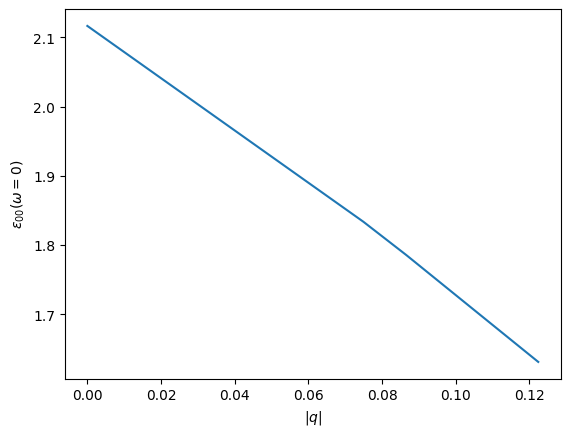

In [19]:
fig,ax = plt.subplots()
em1s.plot_eps(ax)

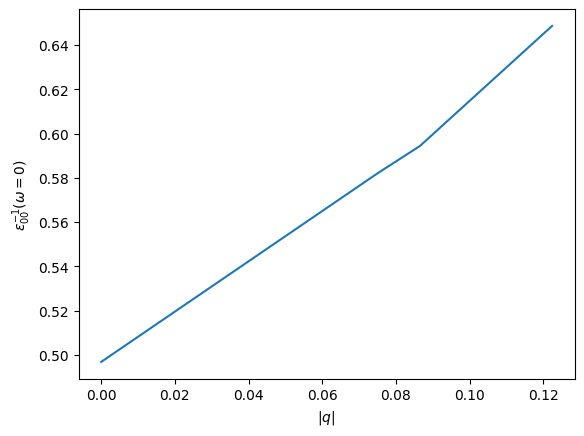

In [22]:
fig,ax = plt.subplots()
em1s.plot_epsm1(ax)

In [39]:
wfdb = YamboWFDB(path=f'{wannier_path}/{seedname}.save/')
cel_vol = abs(np.linalg.det(wfdb.ydb.lat.T))

27 kpoints expanded to 27


Loading Miller Indices: 100%|██████████| 27/27 [00:00<00:00, 38676.98it/s]


In [30]:
cel_vol

np.float32(114.28789)

In [31]:
det_lat = np.linalg.det(wfdb.lat.T)
alat_val = float(wfdb.alat) if np.ndim(wfdb.alat) == 0 else float(wfdb.alat[0])
cell_volume = float(abs(det_lat) * (alat_val ** 3))

AttributeError: 'YamboWFDB' object has no attribute 'lat'

In [33]:
wfdb.ydb.alat

array([3.851738, 3.851738, 3.851738], dtype=float32)

In [35]:
em1s.red_qpoints

array([[-0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [-0.0000000e+00,  0.0000000e+00,  3.3333325e-01],
       [ 1.2754125e-17,  3.3333325e-01,  3.3333325e-01],
       [-0.0000000e+00,  3.3333325e-01, -3.3333325e-01]], dtype=float32)

In [40]:
kmap = np.zeros((wfdb.nkBZ,2), dtype=int)
kmap[:,0]=wfdb.ydb.kpoints_indexes
kmap[:,1]=wfdb.ydb.symmetry_indexes

In [42]:
type(wfdb.ydb)

yambopy.dbs.latticedb.YamboLatticeDB

In [48]:
ydb = YamboLatticeDB.from_db_file(folder=save_path,Expand=True)

27 kpoints expanded to 27


In [51]:
ydb.symmetry_indexes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0])